In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
from typing import Literal
import matplotlib.pyplot as plt

sns.set(style="whitegrid", palette="Set2")

In [46]:
from sklearn.base import BaseEstimator
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import time
from sklearn.preprocessing import OneHotEncoder
from scipy.interpolate import interp1d
from sklearn.metrics import accuracy_score
from typing import Any
from typing import Tuple
import typing

---


Реализуйте логистическую регрессию для двух вариантов поиска оценки параметров:

простой градиентный спуск;
стохастический градиентный спуск с batch_size элементами на каждой итерации.
Останавливайте итерации при выполнении хотя бы одного из двух условий:

количество итераций превзошло число max_iter;
оптимизируемый функционал изменился за итерацию не более чем на tol.

In [ ]:
class LogisticRegression(BaseEstimator):
    """Модель логистической регрессии.

    Параметры:
    method (Literal['gd', 'sgd']): Метод оптимизации ('gd' - градиентный спуск, 
        'sgd' - стохастический градиентный спуск).
    learning_rate (float): Константа скорости обучения, на которую домножаем градиент при обучении
    tol (float): Допустимое изменение функционала между итерациями.
    max_iter (int): Максимальное число итераций.
    batch_size (int): Размер выборки для оценки градиента (используется только при 'sgd').
    fit_intercept (bool): Добавлять ли константу в признаки.
    save_history (bool): Сохранять ли историю обучения.
    """

    def __init__(
        self,
        method: Literal["gd", "sgd"] = "gd",
        learning_rate: float = 0.5,
        tol: float = 1e-3,
        max_iter: int = int(1e4),
        batch_size: int = 64,
        fit_intercept: bool = True,
        save_history: bool = True,
    ):
        """Создает модель и инициализирует параметры."""
        self.method = method
        self.learning_rate = learning_rate
        self.tol = tol
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.fit_intercept = fit_intercept
        self.save_history = save_history
        self.history_t = []  # История обучения
        self.history_lo = []
        self.iter = 0

    @staticmethod
    def _sigmoid(x: np.ndarray) -> np.ndarray:
        """Вычисляет сигмоидную функцию."""
        return np.exp(-np.logaddexp(0, -x))

    def _add_intercept(self, X: np.ndarray) -> np.ndarray:
        """Добавляет свободный коэффициент к матрице признаков.

        Параметры: X (np.ndarray): Исходная матрица признаков.

        Возвращает: np.ndarray: Матрица X с добавленным свободным
        коэффициентом.
        """
        X_copy = np.full((X.shape[0], X.shape[1] + 1), fill_value=1)
        X_copy[:, :-1] = X
        return X_copy
    
    def gd (self, X: np.ndarray, Y: np.ndarray, m: int):
        
        if self.save_history:
            t0 = time.time() # время начала
        self.iter = 0 # чтобы вернуть если выйдем заранее

        for i in range (self.max_iter):

            self.iter += 1

            z = np.dot(X, self.coef_) 
            pr = self._sigmoid(z) # предсказание

            err = pr - Y # ошибка

            gr = 1/m * np.dot(X.T, err) # градиент по тета

            self.coef_ -= self.learning_rate * gr # обновление коэффициентов

            if self.learning_rate * np.linalg.norm(gr) < self.tol: # останавливаемся если разница маленькая
                break
                
            if self.save_history:
                t = time.time()
                self.history_t.append(t - t0) # засекаем время
                
                mse = np.mean(np.square(err))  # ошибка
                self.history_lo.append(mse)

    def cgd (self, X: np.ndarray, Y: np.ndarray, m: int):

        if self.save_history:
            t0 = time.time() # время начала

        self.iter = 0 # чтобы вернуть если выйдем заранее

        for i in range (self.max_iter):

            indices = np.random.choice(m, m, replace=True) # перемешиваем данные 
            X = X[indices]
            Y = Y.iloc[indices].reset_index(drop=True)
            f = self.coef_ # для сравнения

            for j in range(0, m, self.batch_size):

                if j + self.batch_size >= m: # не вылазим за границу
                    break
    
                self.iter += 1

                X_j = X[j:j + self.batch_size] # берем кусок данных
                Y_j = Y[j:j + self.batch_size]

                z = np.dot(X_j, self.coef_) 
                pr = self._sigmoid(z) # предсказание

                err = pr - Y_j # ошибка
                gr = (1 / self.batch_size) * np.dot(X_j.T, err) # градиент по тета

                self.coef_ -= self.learning_rate * gr # обновление коэффициентов

                if self.save_history:
                    mse = np.mean(np.square(err))  # ошибка
                    self.history_lo.append(mse)
                    
                    t = time.time() # засекаем время
                    self.history_t.append(t - t0)
                    
                z = np.dot(X, self.coef_) 
                pr = self._sigmoid(z) # предсказание

                err = pr - Y # ошибка
                mse = np.mean(np.square(err)) 

                if  mse < self.tol or self.iter > self.max_iter: # останавливаемся если разница маленькая или итераций много
                    return
                
                

    def fit(self, X: np.ndarray, Y: np.ndarray) -> "LogisticRegression":
        """Обучает модель логистической регрессии.

        Также, в случае self.save_history=True, добавляет в self.history
        текущее значение оптимизируемого функционала и затраченное время.

        Параметры:
        X (np.ndarray): Матрица признаков.
        Y (np.ndarray): Вектор истинных меток.

        Возвращает:
        LogisticRegression: Обученная модель.
        шпаргалка
        m - строк
        n - столбцов
        """
        if X.shape[0] != Y.shape[0]:
            raise ValueError("Количество строк в X и Y должно совпадать")

        if self.fit_intercept:
            X_copy = self._add_intercept(X)
        else:
            X_copy = X.copy()

        m, n = X_copy.shape
        self.coef_ = np.zeros(n) #начальные значения тета
        
        if (self.method == "gd"):
            self.gd(X_copy, Y, m)
        else:
            self.cgd(X_copy, Y, m)
            """
        if self.fit_intercept == True:
            self.intercept_ = self.coef_[0]
            self.coef_ = self.coef_[1:]
        else:
            self.intercept_ = 0
"""
        self.n_iter_ = self.iter  # Число итераций

        return self
    def predict(self, X: np.ndarray) -> np.ndarray:
        """Возвращает предсказанные классы.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Предсказанные классы.
        """
        if self.fit_intercept:
            X_copy = self._add_intercept(X)
        else:
            X_copy = X.copy()

        if X_copy.shape[1] != self.coef_.shape[0]:
            raise ValueError("Число признаков в X не соответствует числу коэффициентов модели")

        z = np.dot(X_copy, self.coef_) 
        pr = self._sigmoid(z) # вероятность 1

        predictions = []

        for p in pr: # вероятность больше 0,5 - 1, иначе - 0.
            if p >= 0.5:
                predictions.append(1)
            else:
                predictions.append(0)

        predictions = np.array(predictions)

        return predictions

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Возвращает вероятности классов 0 и 1.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Матрица вероятностей классов (n_samples,
        2).
        """
        if self.fit_intercept:
            X_copy = self._add_intercept(X)
        else:
            X_copy = X.copy()

        if X_copy.shape[1] != self.coef_.shape[0]:
            raise ValueError("Число признаков в X не соответствует числу коэффициентов модели")

        z = np.dot(X_copy, self.coef_) 
        pr = self._sigmoid(z) # вероятность 1

        prob_predictions = np.column_stack((1 - pr,  pr)) # вероятность 0 - 1-вероятность 1

        return prob_predictions
    def hist (self):
        return self.history_lo

**Для данного задания будем рассматривать** `diabetes_binary_5050split_health_indicators_BRFSS2015.csv`

Признаки, представленные в датасете.

**Показатели здоровья**

- `HighBP`: Высокое кровяное давление (`1` = да, `0` = нет).

- `HighChol`: Высокий уровень холестерина (`1` = да, `0` = нет).

- `CholCheck`: Проверка уровня холестерина за последние 5 лет (`1` = да, `0` = нет).

- `BMI`: Индекс массы тела (рассчитывается как вес (кг) / рост² (м²)).

- `GenHlth`: Общая оценка здоровья (`1` = отличное, `2` = очень хорошее, ..., `5` = плохое).

**Образ жизни**
- `Smoker`: Статус курения (`1` = выкурил ≥100 сигарет за жизнь, `0` = нет).

- `PhysActivity`: Физическая активность вне работы (`1` = да, `0` = нет).

- `Fruits`: Регулярное употребление фруктов (`1` = не менее 1 раз в день, `0` = реже).

**Доступ к медицине**
- `AnyHealthcare`: Наличие медицинской страховки (`1` = да, `0` = нет).

- `NoDocbcCost`: Отказ от визита к врачу из-за стоимости (`1` = да, `0` = нет).



Выполните предобработку данных.

In [48]:
dataset = pd.read_csv("archive/diabetes_012_health_indicators_BRFSS2015.csv")
dataset.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [49]:
X = dataset.drop('Diabetes_012', axis=1)
y = dataset['Diabetes_012']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
categorical = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'PhysActivity', 'Fruits', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'Stroke', 'HeartDiseaseorAttack', 'Veggies', 'HvyAlcoholConsump', 'DiffWalk', 'Sex']
real = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
target = "Diabetes_012"

In [52]:
encoder = OneHotEncoder(drop="first", sparse_output=False)
train_cat = encoder.fit_transform(X_train[categorical])
test_cat = encoder.transform(X_test[categorical])

In [53]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[real])
X_test_scaled = scaler.transform(X_test[real])

In [54]:
X_train = np.hstack([X_train_scaled, train_cat])
X_test = np.hstack([X_test_scaled, test_cat])

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 107ac5fe506b9f95aacd88457e0ec142 -->
**2.** Обучите две модели логистической регрессии с помощью методов
* простой градиентный спуск;
* стохастический градиентный спуск.

In [55]:
model = LogisticRegression(method="gd", learning_rate=0.01, tol=1e-4, max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(learning_rate=0.01, max_iter=1000, tol=0.0001)

In [56]:
model_2 = LogisticRegression(method="cgd", learning_rate=0.01, tol=1e-4, max_iter=1000)
model_2.fit(X_train, y_train)

LogisticRegression(learning_rate=0.01, max_iter=1000, method='cgd', tol=0.0001)

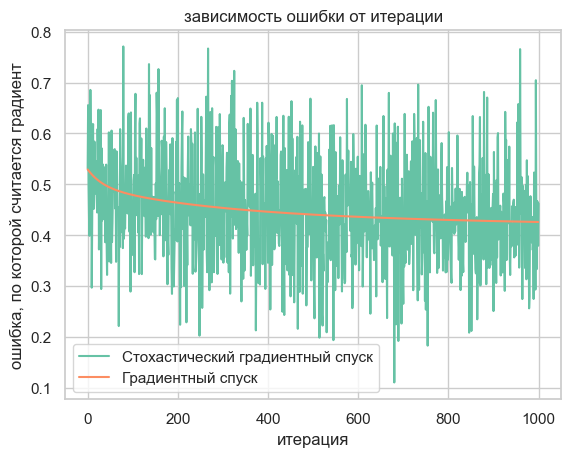

In [57]:
plt.plot(model_2.history_lo, label='Стохастический градиентный спуск')
plt.plot(model.history_lo, label='Градиентный спуск')

plt.xlabel('итерация')
plt.ylabel('ошибка, по которой считается градиент')
plt.title('зависимость ошибки от итерации')
plt.legend()
plt.show()

Для стохаотического спуска выглядит примерно ужасно. Попробую усреднить результаты.

In [58]:
losses_3 = []
tm_3 = []

losses_4 = []
tm_4 = []
for i in range (100):
    model_3 = LogisticRegression(method="gd", learning_rate=0.01, tol=1e-3, max_iter=100)
    model_3.fit(X_train, y_train)
    losses_3.append(model_3.history_lo)
    tm_3.append(model_3.history_t)

    model_4 = LogisticRegression(method="cgd", learning_rate=0.01, tol=1e-3, max_iter=100)
    model_4.fit(X_train, y_train)
    losses_4.append(model_4.history_lo)
    tm_4.append(model_4.history_t)
    
mean_losses_3 = np.mean(losses_3, axis=0)
mean_losses_4 = np.mean(losses_4, axis=0)

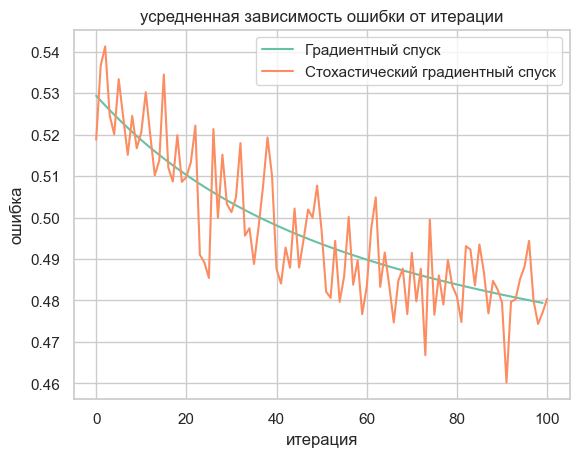

In [59]:
plt.plot(mean_losses_3, label='Градиентный спуск')
plt.plot(mean_losses_4, label='Стохастический градиентный спуск')

plt.xlabel('итерация')
plt.ylabel('ошибка')
plt.title('усредненная зависимость ошибки от итерации')
plt.legend()
plt.show()

тут уже гораздо лучше, можно хотя бы увидеть что ошибка действительно убывает.

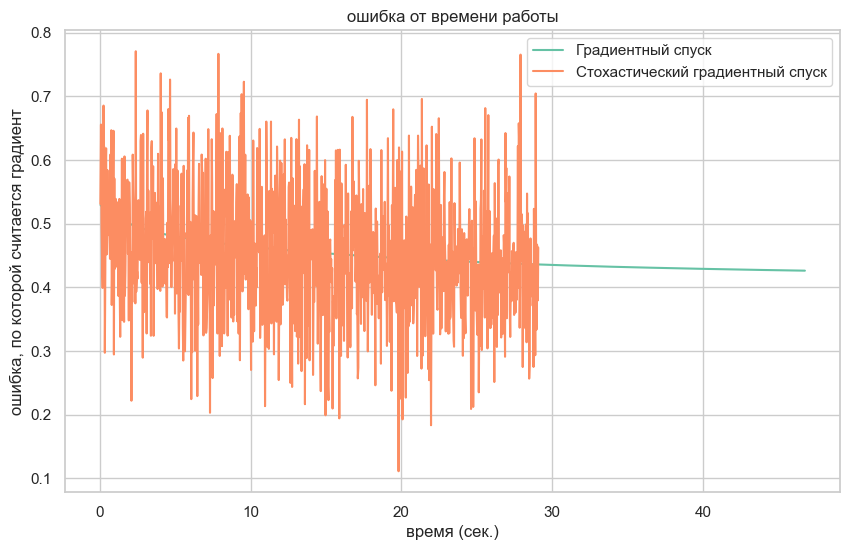

In [60]:
plt.figure(figsize=(10, 6))
plt.plot(model.history_t, model.history_lo, label='Градиентный спуск')
plt.plot(model_2.history_t, model_2.history_lo, label='Стохастический градиентный спуск')
plt.xlabel("время (сек.)")
plt.ylabel("ошибка, по которой считается градиент")
plt.title("ошибка от времени работы")
plt.legend()
plt.show()

Аналогично постою усредненный график.

In [61]:
def interp(times, losses, grid):
    interp_func = interp1d(times, losses, kind='linear', fill_value='extrapolate')
    return interp_func(grid)

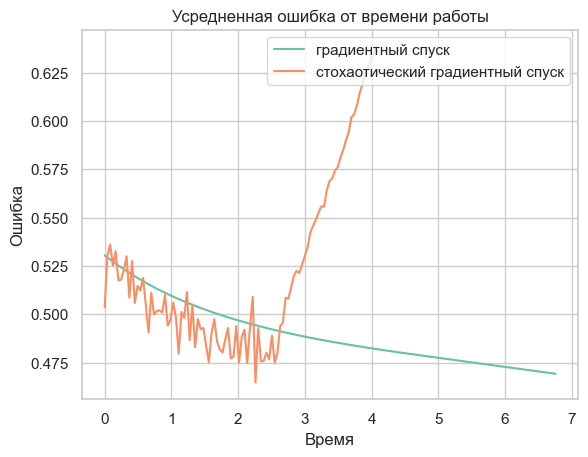

In [62]:
max_time_3 = max(tm_3[i][-1] for i in range(100))
time_grid_3 = np.linspace(0, max_time_3, 100)

interp_3 = np.array([interp(tm, loss, time_grid_3) for tm, loss in zip(tm_3, losses_3)])
mean_losses_3 = np.mean(interp_3, axis=0)

max_time_4 = max(tm_4[i][-1] for i in range(100))
time_grid_4 = np.linspace(0, max_time_4, 100)

interp_4 = np.array([interp(tm, loss, time_grid_4) for tm, loss in zip(tm_4, losses_4)])
mean_losses_4 = np.mean(interp_4, axis=0)


plt.plot(time_grid_3, mean_losses_3, label="градиентный спуск")
plt.plot(time_grid_4, mean_losses_4, label="стохаотический градиентный спуск")
plt.xlabel("Время")
plt.ylabel("Ошибка")
plt.title("Усредненная ошибка от времени работы")
plt.legend()
plt.show()

Сделайте выводы. Что будет при обучении на датасете, если увеличить количество объектов, а число признаков оставить прежним?

Для стохаотического градиентного спуска ошибки меняются довольно рандомно, но в целом при усреднении убывание. Для обычного градиентного спуска функция ошибок вообще монотонная. Можносделать выводы, что модели обучаются коректно.
На графике от времени у стохаотического спуска происходит огромный скачок в конце, я не могу понять почему. Мне кажется, это больше похоже на выброс, чем на осмысленное поведение графика.
Если увеличить выборку, то в общем случае это приведет к улучшению точности модели. Для градиентного спуска это приведет к замедлению обучения, для стохаотического гс - нет.


Исследуйте влияние размер шага (`learning_rate`) на качество модели для двух режимов обучения (простой и стохастический градиентный спуск).

In [63]:
learning_rate_list = np.logspace(-5, 3, 8)

In [64]:
gd_losses = []
sgd_losses = []

for lr in learning_rate_list:
    print(lr)
    model_3 = LogisticRegression(method="gd", learning_rate=lr, tol=1e-3, max_iter=100)
    model_3.fit(X_train, y_train)
    y_pred = model_3.predict(X_test)
    gd_losses.append(accuracy_score(y_test, y_pred))

    model_4 = LogisticRegression(method="cgd", learning_rate=lr, tol=1e-3, max_iter=100)
    model_4.fit(X_train, y_train)
    y_pred = model_4.predict(X_test)
    sgd_losses.append(accuracy_score(y_test, y_pred))


1e-05
0.00013894954943731373
0.0019306977288832496
0.026826957952797246
0.3727593720314938
5.179474679231202
71.96856730011514
1000.0


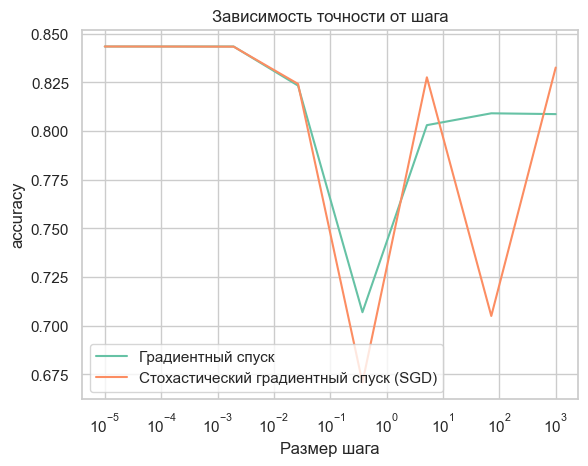

In [65]:
plt.plot(learning_rate_list, gd_losses, label="Градиентный спуск")
plt.plot(learning_rate_list, sgd_losses, label="Стохастический градиентный спуск (SGD)")

plt.xscale('log')
plt.xlabel("Размер шага")
plt.ylabel("accuracy")
plt.title("Зависимость точности от шага")
plt.legend()
plt.show()

При маленьких шагах точность довольно высокая, при приближении к нулю начинает падать, при шагах больше 1 ведет себя вообще доольно хаотично. Мне кажется, что странно, когда очередная ошибка влияет на коэффиценты так же или больше чем все шаги, что были до. Это какое-то сильное ub, мне кажется.

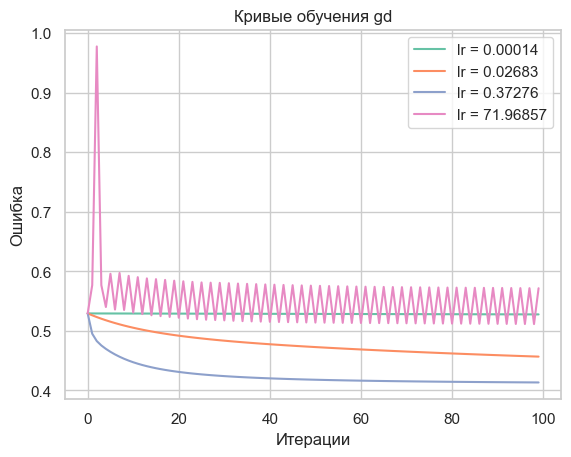

In [66]:
selected_lr = [learning_rate_list[1], learning_rate_list[3], learning_rate_list[4], learning_rate_list[6]]
history = []
for lr in selected_lr:

    model = LogisticRegression(method="gd", learning_rate=lr, tol=1e-6, max_iter=100)
    model.fit(X_train, y_train)
    history.append([model.history_t, model.history_lo])
    plt.plot(model.history_lo, label=f"lr = {lr:.5f}")

plt.xlabel("Итерации")
plt.ylabel("Ошибка")
plt.title("Кривые обучения gd")
plt.legend()
plt.grid(True)
plt.show()


In [67]:
print(f"{'Learning rate':<15}{'Итераций':<15}{'Время (сек)':<15}{'Финальная ошибка':<20}")

for lr, (times, losses) in zip(selected_lr, history):
    num_iters = len(losses)
    total_time = times[-1]
    final_loss = losses[-1]

    print(f"{lr:<15.5f}{num_iters:<15}{total_time:<15.5f}{final_loss:<20.5f}")


Learning rate  Итераций       Время (сек)    Финальная ошибка    
0.00014        100            4.47322        0.52776             
0.02683        100            4.45448        0.45687             
0.37276        100            4.41240        0.41351             
71.96857       100            4.45264        0.57166             


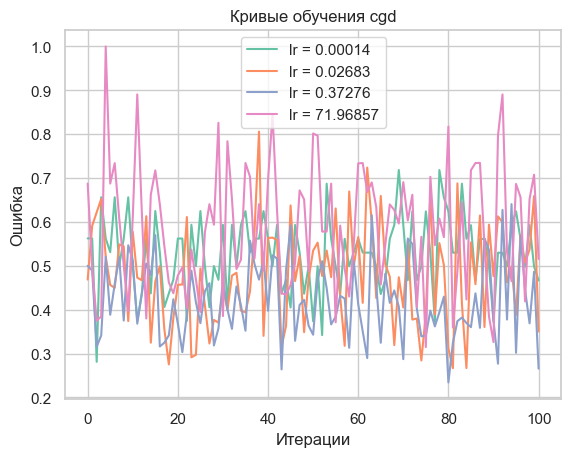

In [68]:
selected_lr = [learning_rate_list[1], learning_rate_list[3], learning_rate_list[4], learning_rate_list[6]]
history_2 = []

for lr in selected_lr:

    model = LogisticRegression(method="cgd", learning_rate=lr, tol=1e-6, max_iter=100)
    model.fit(X_train, y_train)
    history_2.append([model.history_t, model.history_lo])
    plt.plot(model.history_lo, label=f"lr = {lr:.5f}")

plt.xlabel("Итерации")
plt.ylabel("Ошибка")
plt.title("Кривые обучения cgd")
plt.legend()
plt.grid(True)
plt.show()


In [69]:
print("Сравнение скоростей сходимости (GD и SGD):")
print(f"{'Метод':<10}{'Learning rate':<15}{'Итераций':<15}{'Время (сек)':<15}{'Финальная ошибка':<20}")

for lr, (times, losses) in zip(selected_lr, history):
    num_iters = len(losses)
    total_time = times[-1]
    final_loss = losses[-1]

    print(f"{'GD':<10}{lr:<15.5f}{num_iters:<15}{total_time:<15.5f}{final_loss:<20.5f}")

for lr, (times, losses) in zip(selected_lr, history_2):
    num_iters = len(losses)
    total_time = times[-1]
    final_loss = losses[-1]

    print(f"{'SGD':<10}{lr:<15.5f}{num_iters:<15}{total_time:<15.5f}{final_loss:<20.5f}")


Сравнение скоростей сходимости (GD и SGD):
Метод     Learning rate  Итераций       Время (сек)    Финальная ошибка    
GD        0.00014        100            4.47322        0.52776             
GD        0.02683        100            4.45448        0.45687             
GD        0.37276        100            4.41240        0.41351             
GD        71.96857       100            4.45264        0.57166             
SGD       0.00014        101            2.68130        0.46673             
SGD       0.02683        101            2.89094        0.35026             
SGD       0.37276        101            3.35897        0.26567             
SGD       71.96857       101            4.91863        0.51563             


Какой learning_rate стоит выбирать в зависимости от способа обучения модели? Чем плохи маленькие и большие learning_rate?

Судя по моим графикам в обоих случаях стоит взять lr = 0.37. В градиентном спуске это очевидно, для стохаотического градиентного спуска не настолько, но видно, что синяя кривая ниже всех остальных. По-хорошему нужно строить усредненный график...  
Маленькие шаги плохи, потому что если посмотреть на зеленую кривую на первом графике, то видно, что ошибка почти не меняется. Это логично, на каждом из шагов происходит слишом маленькое изменение коэффициентов, из-за того что очередной градиент вносит слишком маленький вклад. В этом случае обучение будет проходить очень медленно.
Для больших шагов, на каждом шаге, наоборот, очередной градиент вносит слишком большой вклад, как будто перечеркивая все, что было до. Например, когда шаг в районе 70, получается что градиент в 70 раз важнее коэффициентов, которые были до. Из-за этого обучение, скорее всего, будет проходить скачкообразно и тоже довольно медленно. То же самое можно увидеть в таблице по меделям.

Рассмотрите наилучшую модель с предыдущего шага. Визуализируйте значения полученных коэффициентов.  
В моем случае это обычный градиентный спуск с шагом 0.3727593720314938.

In [70]:
best_learning_rate = learning_rate_list[4]

model = LogisticRegression(method="gd", learning_rate=best_learning_rate, tol=1e-3, max_iter=100)
model.fit(X_train, y_train)

coefficients = model.coef_

coefficients = coefficients[1:]

cat_feature_names = encoder.get_feature_names_out(categorical)
feature_names = list(real) + list(cat_feature_names)

In [71]:
coefficients

array([-0.02125268,  0.23651639,  0.53758314, -0.12524163, -0.2020885 ,
        0.98302859,  0.72506924, -0.32228448, -0.02591903, -0.44698179,
       -0.19994896, -0.41160599, -0.04217653, -0.56473645,  0.14365883,
        0.51634749,  0.29813268,  0.19415547,  0.50444929, -0.35658659,
       -0.2535437 ,  0.49524361,  0.08248357, -0.62356283])

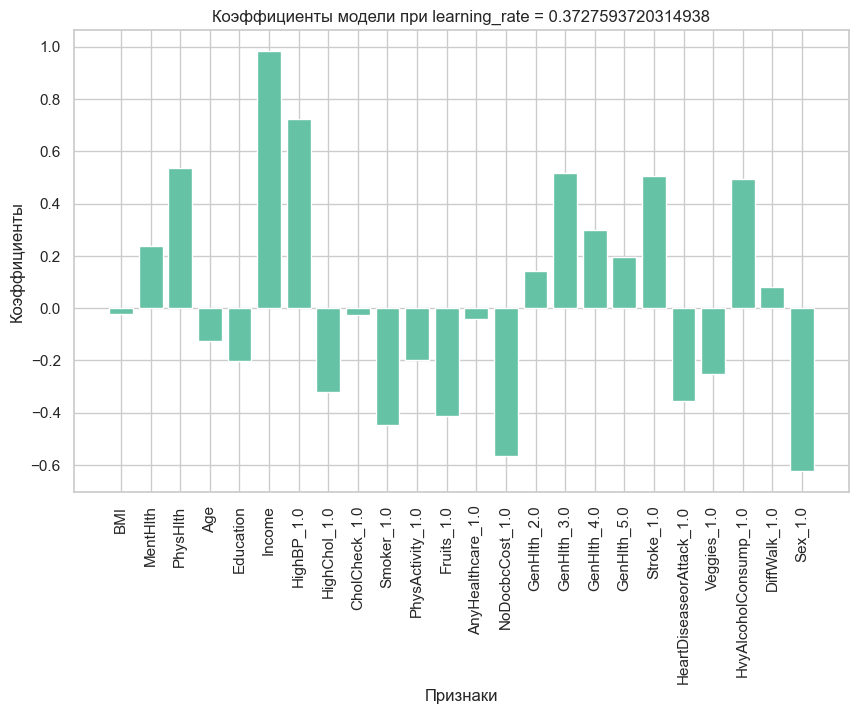

In [72]:
plt.figure(figsize=(10, 6))
plt.bar(range(len(coefficients)), coefficients, tick_label=feature_names)
plt.xlabel('Признаки')
plt.ylabel('Коэффициенты')
plt.title(f'Коэффициенты модели при learning_rate = {best_learning_rate}')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

Как можно проинтерпретировать полученные результаты относительно решаемой задачи?  
Положительные коэффициенты:   
Income: богатые люди ведут более нездоовый образ жизни? очень странно. 
HighBP: логично.     
Genhlth: тоже логино. 
Stroke: мне кажется ту немного наоборот. проблемы с инсулином могут вызывать проблемы с сердцем.  
MentHlth: если честно, не представляю откуда появляется корреляция. 
PhysHlth: аналогчно.  
HvyAlcoholConsump: вполне логично. 
Коэффициенты, которые почти нулевые:  
ИМТ: странно для меня, но ИМТ не влияет на диабет практически. 
CholCheck: тоже нелогично, проверка холестерина должна бы отрицательно влиять, но он влияет очень мало. 
AnyHealthcare:аналогично. 
DiffWalk: ну тут логично некоторое положительное влияниие, хоть и небольшое.  
Отрицательные коэффициенты:  
Возраст: влияет, но не сильно, значит в более старшем возрасте вероятность заболеть диабетом чуть выше, но не очень сильно. 
Образование: может образованные люди на более ранних этапах могут заметить проблему. 
HighChol: наверное люди с выоким холестерином лучше следят за смоим здоровьем в целом. 
Smoker: очень странно, я не знаю почему. 
Fruits: людт едящие врукты ведут более здоровый образ жизни, потебляя меньше сахара. 
NoDocbcCost: Я нинаю, это очень странно. 
HeartDiseaseorAttak: Люди  которых порблемы с сердцем более активно следят за здоровьем. Но это как будто противоречит Stroke.  
Veggies: логично?  
Sex: Женщины имеют более высокий риск диабета.  

Сравните данную модель с бейзлайном, который в качестве предсказания выдает самый частый класс на обучающей выборке.

In [73]:
most_frequent_class = y_train.mode()[0]
print(f"Самый частый класс: {most_frequent_class}")

Самый частый класс: 0.0


In [74]:
most_frequent_class_count = (y_test == most_frequent_class).sum()
b_rate = most_frequent_class_count / len(y_test)

y_pred_model = model.predict(X_test)
model_accuracy = accuracy_score(y_test, y_pred_model)

In [75]:
print(f"Точность бейзлайна: {b_rate}")
print(f"Точность модели: {model_accuracy}")

Точность бейзлайна: 0.8434839167455062
Точность модели: 0.7069339325134028


Насколько хорошее получилось качество обученной модели? Получается плохое, если базлайн предсказывает лучше...

В исходной выборке оставьте два вещественных признака, которые имеют наибольшее влияние на предсказание в предыдущем пункте. Обучите на них модель на 10000 итерациях. 

In [76]:
iters = [10, 20, 500, 1000, 5000, 10000]
pr = []

In [77]:
top_2_ind = [0, 1]
X_train_important = X_train[:, top_2_ind]
X_test_important = X_test[:, top_2_ind]

model_important = LogisticRegression(max_iter=10000, tol=1e-4)
model_important.fit(X_train_important, y_train)

LogisticRegression(tol=0.0001)

In [78]:
for i in iters:
    model_important = LogisticRegression(max_iter=i, tol=1e-4)
    model_important.fit(X_train_important, y_train)
    probs = model_important.predict_proba(X_train_important)
    mean_prob = np.mean(probs)
    pr.append(mean_prob)

In [79]:
def plot_decision_boundary(
    model: Any,
    X: np.ndarray,
    y: np.ndarray,
    figsize: Tuple[int, int] = (10, 6),
    title: str = "Предсказания модели линейной регрессии",
    xlabel: str = "Признак 1",
    ylabel: str = "Признак 2",
    cmap: str = "summer",
    colorbar_label: str = "Вероятность класса 1",
) -> None:
    """Визуализирует предсказание модели бинарной классификации.

    Параметры:
    model (Any): Обученная модель с методом predict_proba.
    X (np.ndarray): Матрица признаков (только первые два признака используются для визуализации).
    y (np.ndarray): Целевые метки.
    figsize (Tuple[int, int]): Размер графика (по умолчанию (10, 6)).
    title (str): Заголовок графика (по умолчанию "Предсказания модели линейной регрессии").
    xlabel (str): Подпись оси X (по умолчанию "Признак 1").
    ylabel (str): Подпись оси Y (по умолчанию "Признак 2").
    cmap (str): Цветовая схема (по умолчанию "summer").
    colorbar_label (str): Подпись цветовой шкалы (по умолчанию "Вероятность класса 1").
    """

    # Установка границ
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Создание сетки
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))

    # Предсказание вероятностей для сетки
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)

    # Построение графика
    plt.figure(figsize=figsize)
    plt.imshow(Z, extent=(x_min, x_max, y_min, y_max), origin="lower", cmap=cmap, alpha=0.8)

    # Визуализация исходных точек
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap=cmap, s=60, alpha=0.8)

    # Настройка оформления
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.grid(False)
    plt.colorbar(label=colorbar_label)
    plt.show()

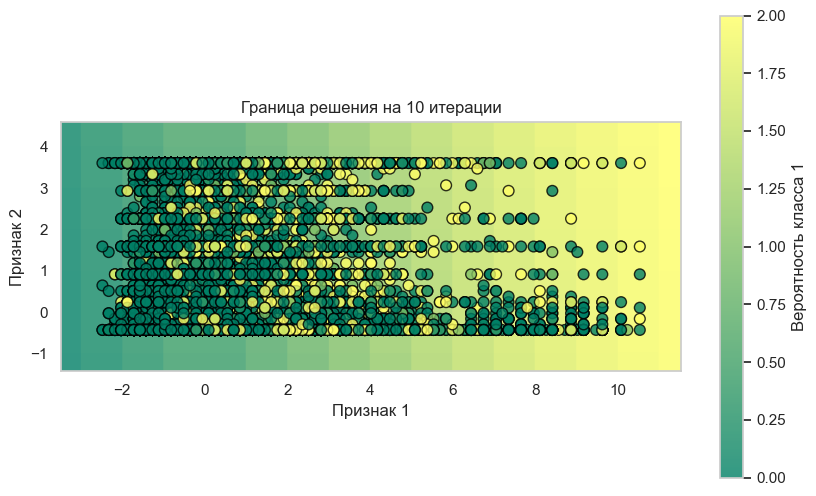

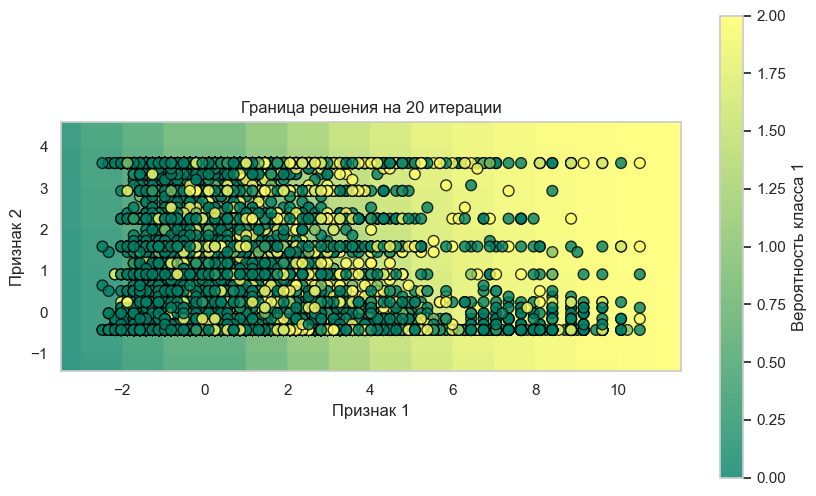

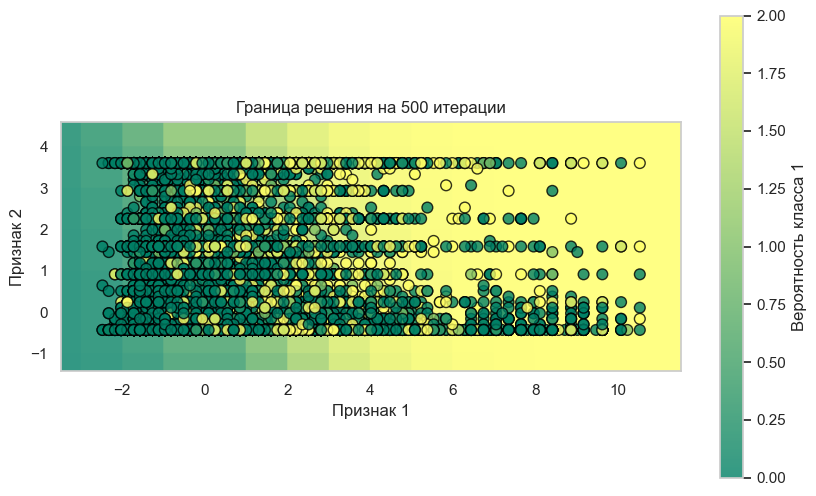

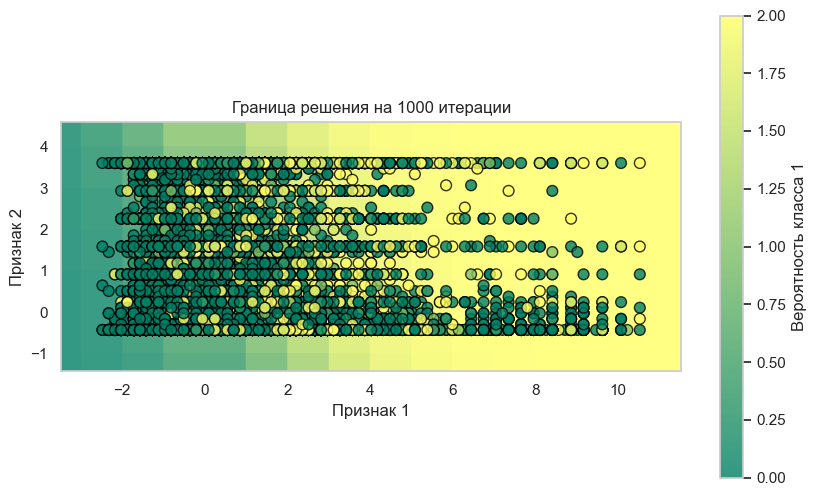

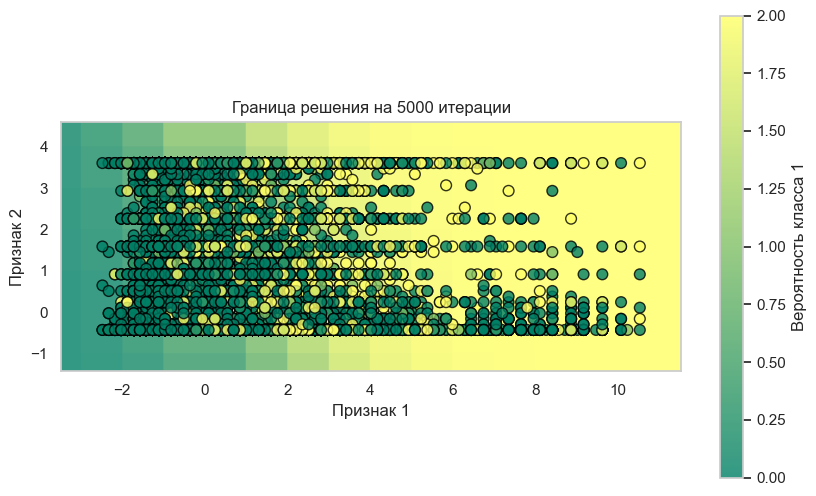

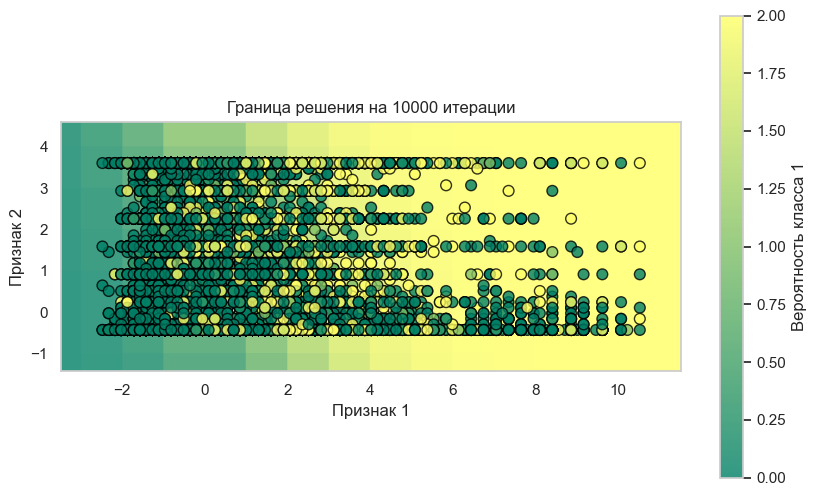

In [80]:
for iter_num in iters:
    model_important = LogisticRegression(max_iter=iter_num, tol=1e-4)
    model_important.fit(X_train_important, y_train)

    plot_decision_boundary(model_important, X_train_important, y_train, 
                           title=f"Граница решения на {iter_num} итерации")

1. Логическая регрессия довольно чувстительна к шагу. Если его взять слишком маленьким или слишком большим, то модель будет обучаться медленно.
2. Существует серьезная разница между градиентным спуском и стохаотическим градиентным спуском. Стохаотическая можель учится "скачками". То есть точность то вознастает, то убывает, но в целом есть динамика к убыванию.
3. Иногда не имеет смысла строить сложные модели (или наоорот, нужно строить что-то сильно сложнее), потому что самое простое что может быть - базлайн выигрывает по сравнению с построенной моделью. Это может быть потому-то данные были плохо обработаны сначала или может признаки нплохо отражают реальную сиуацию (например может наличие или отсутствие диабета определется наследственностью и больше ничем).


---


В этой задаче вам предлагается реализовать регрессию Хьюбера, а также применить ее к данным с выбросами. Для начала реализуйте класс по шаблону снизу. Обратите внимание, что класс `HuberRegression` &mdash; наследник класса `BaseEstimator`, это с легкостью позволит использовать наш класс в различных пайплайнах библиотеки `sklearn`.

**1.** Задача оптимизации для регрессии Хьюбера выглядит следующим образом:
$$\sum_{i=1}^n R\left(Y_i - x_i^T\theta\right) \rightarrow \min_\theta,$$
где $R(x)$ &mdash; функция потерь Хьюбера, определяемая как
$$R(x) = \frac{x^2}{2} I\left\{|x| < c\right\} + c \left(|x| - \frac{c}{2}\right)I\left\{|x| > c\right\}.$$

Выпишите формулы для градиентного и стохастического градиентного спусков. В чем польза такой функции потерь?

Градиент $R_i$ (R для $i$го $x$ и $Y$) по $\theta$ равен $x$ при $|x| < c$ и $sign(x)c$ при $|x| > c$ (явно видно из фунции R).
Градиент $ L(\theta) $ по $\theta$:
$$
\nabla_\theta L(\theta) = - \sum_{i=1}^n x_i \cdot \frac{d}{dx} R(Y_i - x_i^T \theta)\
$$
Градиентный спуск ($\eta$ - шаг обучения):
$$
\theta^{(k+1)} = \theta^{(k)} - \eta \nabla_\theta L(\theta^{(k)})
$$
Стохаотическй градиентный спуск:
$$
\theta^{(k+1)} = \theta^{(k)} - \eta \cdot x_i \cdot \frac{d}{dx} R(Y_i - x_i^T \theta^{(k)}).
$$

MSE очень чувствительна к выбросам, потому что возводит все в квадрат, но в нуле у нее есть производная.
MAE гораздо меннее чувствительна к выбросам, потому что линейная, но в нуле у модуля есть разрыв производной, поэтому с ней плохо работает градиентный спуск.
R на маленьких отклонениях берет квадрат (значит можно брать производную), ну и поскольку маленькие отклонения то выбросы не будут влиять, а на больших отклонениях берет линейно (производная существует везде кроме нуля, так что все ок), и к выбросам более устойчиво получается. Ну по сути R решает проблему сильной чувствительности MSE к выбросам, при этом не создавая проблемы отсутствия производной в нуле.

(я сначала делала задачу 6, а потом задачу 5, поэтому некоторые вещи в классе написаны зря (они уже были реализованы), но они работают, поэтому я не стала переписывать)

In [ ]:
class HuberRegression(BaseEstimator):
    """Класс, реализующий линейную регрессию с функцией потерь Хьюбера."""

    def __init__(self, c: float = 1.0, fit_intercept: bool = True, max_iter: int = 1000, learning_rate: float = 0.01) -> None:
        """Инициализирует модель.

        Параметры: c (float): Константа из функции потерь Хьюбера.
        fit_intercept (bool): Добавлять ли константный признак. max_iter
        (int): Максимальное число итераций оптимизации.
        """
        self.c = c
        self.fit_intercept = fit_intercept
        self.max_iter = max_iter

        self.learning_rate = learning_rate
    
    def loss_gr(self, x: float) -> float:
        if abs(x) <= self.c:
            return x
        return self.c * np.sign(x)
    
    def sum_loss_gr (self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        A = np.zeros(X.shape[1])
        for i in range(X.shape[0]):
            B = self.loss_gr(y[i] - X[i].dot(self.coef_))
            A -= X[i] * B
        return A
    
    def fit(self, X: np.ndarray, y: np.ndarray) -> "HuberRegression":
        """Обучает модель.

        Параметры:
        X (np.ndarray): Матрица признаков.
        y (np.ndarray): Вектор целевой переменной.

        Возвращает:
        HuberRegression: Обученная модель.

        шпаргалка, чтобы не забыть
        копия всего!!!! +
        + столбец если свободный  +
        коэффициенты нулями +
        функция производной ошибки +
        функция производноц всего +
        итерации спуска +
        - столбец если свободный +
        шаг обучения в поля +
        """
        if X.shape[0] != y.shape[0]:
            raise ValueError("Количество строк в X и y должно совпадать")

        if self.fit_intercept == True:
            A = np.ones((X.shape[0], 1))
            X2 = np.hstack([A, X])

        self.coef_ = np.zeros(X2.shape[1])

        for i in range (1, self.max_iter):
            self.coef_ -= self.learning_rate * self.sum_loss_gr(X2, y)

        if self.fit_intercept == True:
            self.intercept_ = self.coef_[0]
            self.coef_ = self.coef_[1:]
        else:
            self.intercept_ = 0
    
        self.n_iter_ = self.max_iter  # Число итераций
        
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Делает предсказание на новых данных.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Вектор предсказанных значений.
        """
        X2 = X.copy()

        if X2.shape[1] != self.coef_.shape[0]:
            raise ValueError("Число признаков в X не соответствует числу коэффициентов модели")

        A = np.ones((X2.shape[0], 1))
        X2 = np.hstack([A, X2])

        B = np.hstack([self.intercept_, self.coef_])
        pred = X2.dot(B)
        
        return pred

Загрузите данные из файлов train.csv, test.csv.

In [82]:
train = pd.read_excel("train.xlsx")
test = pd.read_excel("test.xlsx")
train.head()

,feature_1,feature_2,feature_3,target
0,2.320800,-1.098571,0.117091,162.910894
1,0.625119,-0.782367,-0.813596,21.113006
2,-0.807648,-0.185054,-1.446535,-36.128990
3,-0.291837,-1.616474,-0.761492,-56.474495
4,0.938747,0.087531,0.607112,189.589573


Посмотрите на зависимость целевой переменной от каждого признака.

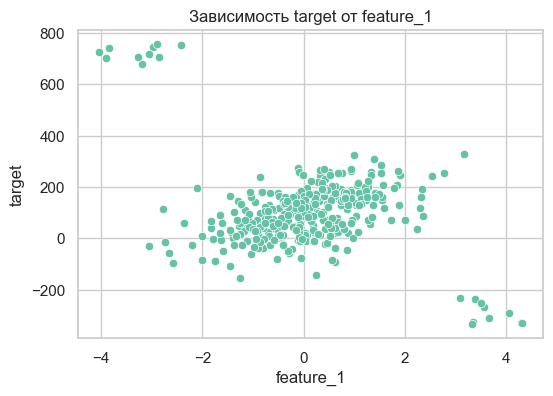

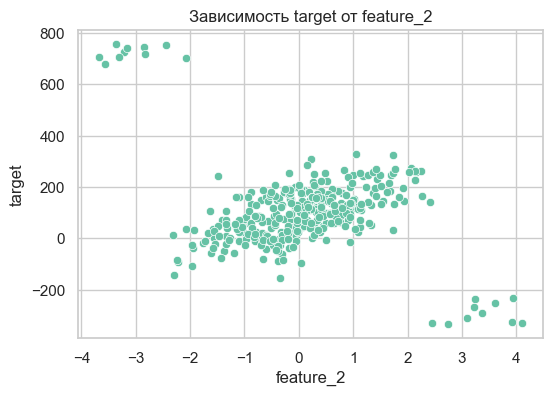

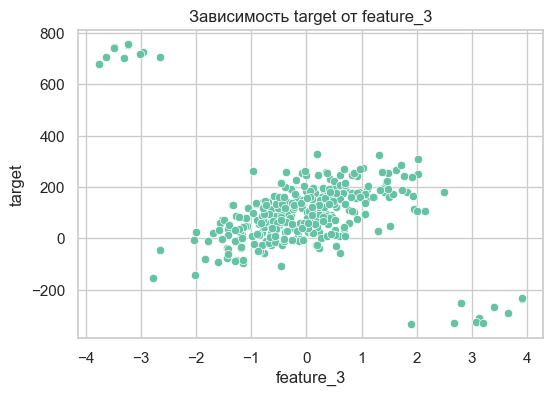

In [83]:
for col in ["feature_1", "feature_2", "feature_3"]:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=train[col], y=train["target"])
    plt.title(f"Зависимость target от {col}")
    plt.show()

Что можно сказать о наличии возможных выбросов? 

Мне кажется, выбросами стоит считать скопления точек в правом и левом углах графиков. Их слишком много, чтобы считать их выбросами в чистом виде (в моей картине мира), это больше похоже на группы точек, лежащие далеко от основной зависимости. Наверное, в идеальном мире нужно для каждой из трех групп строить отдельную модель, но тут такого не просят.
Из-за выбросов модель может быть смещена куда-то (тут эта проблема должна возникнуть с меньшей остротой, потому что группы выбросов уравновешивают друг друга).

**4.** Обучите простую линейную регрессию и посчитайте качество на тестовой выборке по метрике MSE.

In [84]:
X_train = train.drop(columns="target")
y_train = train["target"]

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [85]:
X_test = test.drop(columns="target")
y_test = test["target"]

y_pred_lr = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred_lr)

print(mse)
print(mse**(1/2))

17025.80661012894
130.48297440711926


По сравнению с диапазоном таргета (примерно [-400; 800]) ошибка получается немаленькой, но и не безумно большой. Качество у модели не очень хорошее, но, если честно, я ожидала что будет сильно хуже. Мне кажется группы точек действительно сильно уравновешивают друг друга.

Теперь обучите линейную регресcию Хьюбера и посчитайте качество на тестовой части по метрикe MSE.

In [86]:
huber_model = HuberRegression(c=1.0, fit_intercept=True, max_iter=1000)
huber_model.fit(X_train, y_train)

HuberRegression()

In [87]:
y_pred_hr = huber_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred_hr)

print(mse)
print(mse**(1/2))

22.793791765148843
4.77428442440842


После обучения предыдущей модели казалось, что ошибки не громадные, но сейчас кажется, что были очень серьезными. Теперь выбросы влияют на модель гораздо меньше, и точность у модели гораздо выше. Группы точек всё-таки влияют, особенно если считать ошибку как квадрат.

Для обучающей выборки постройте графики , на которых изобразите зависимость истинного и предсказанного значения таргета от каждого признака.

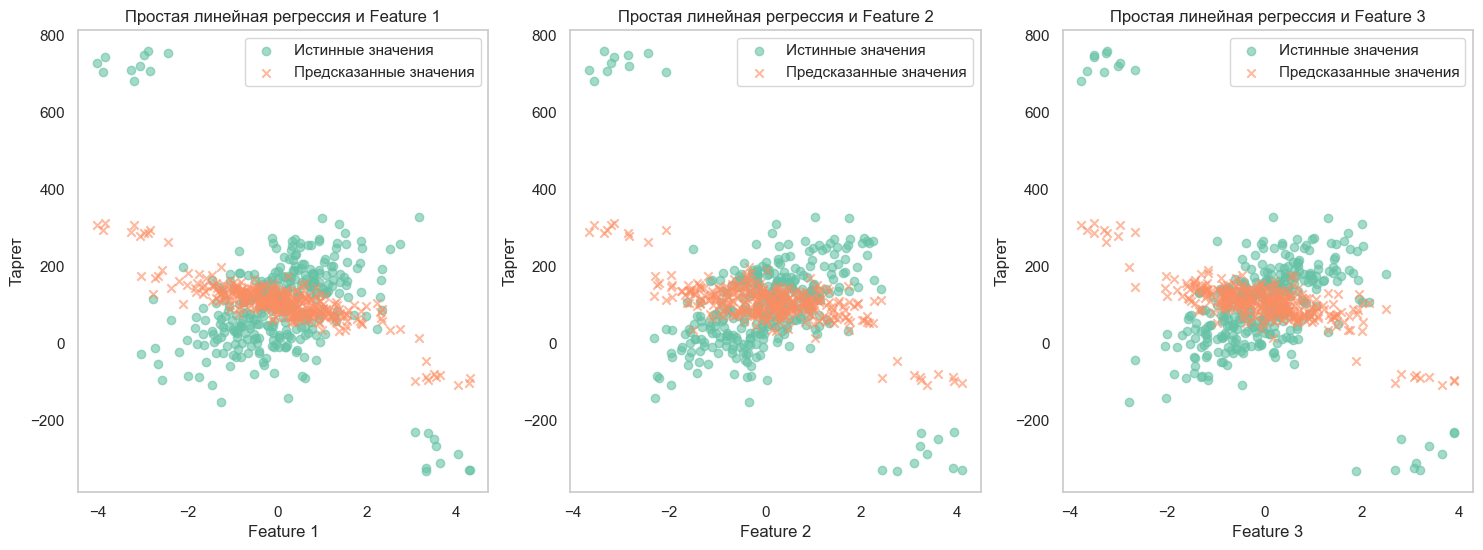

In [88]:
y_pred_lr = model.predict(X_train)
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.scatter(X_train['feature_1'], y_train, label="Истинные значения", alpha=0.6, marker='o')
plt.scatter(X_train['feature_1'], y_pred_lr, label="Предсказанные значения", alpha=0.6, marker='x')
plt.xlabel("Feature 1")
plt.ylabel("Таргет")
plt.title("Простая линейная регрессия и Feature 1")
plt.legend()
plt.grid()

plt.subplot(1, 3, 2)
plt.scatter(X_train['feature_2'], y_train, label="Истинные значения", alpha=0.6, marker='o')
plt.scatter(X_train['feature_2'], y_pred_lr, label="Предсказанные значения", alpha=0.6, marker='x')
plt.xlabel("Feature 2")
plt.ylabel("Таргет")
plt.title("Простая линейная регрессия и Feature 2")
plt.legend()
plt.grid()

plt.subplot(1, 3, 3)
plt.scatter(X_train['feature_3'], y_train, label="Истинные значения", alpha=0.6, marker='o')
plt.scatter(X_train['feature_3'], y_pred_lr, label="Предсказанные значения", alpha=0.6, marker='x')
plt.xlabel("Feature 3")
plt.ylabel("Таргет")
plt.title("Простая линейная регрессия и Feature 3")
plt.legend()
plt.grid()

plt.show()

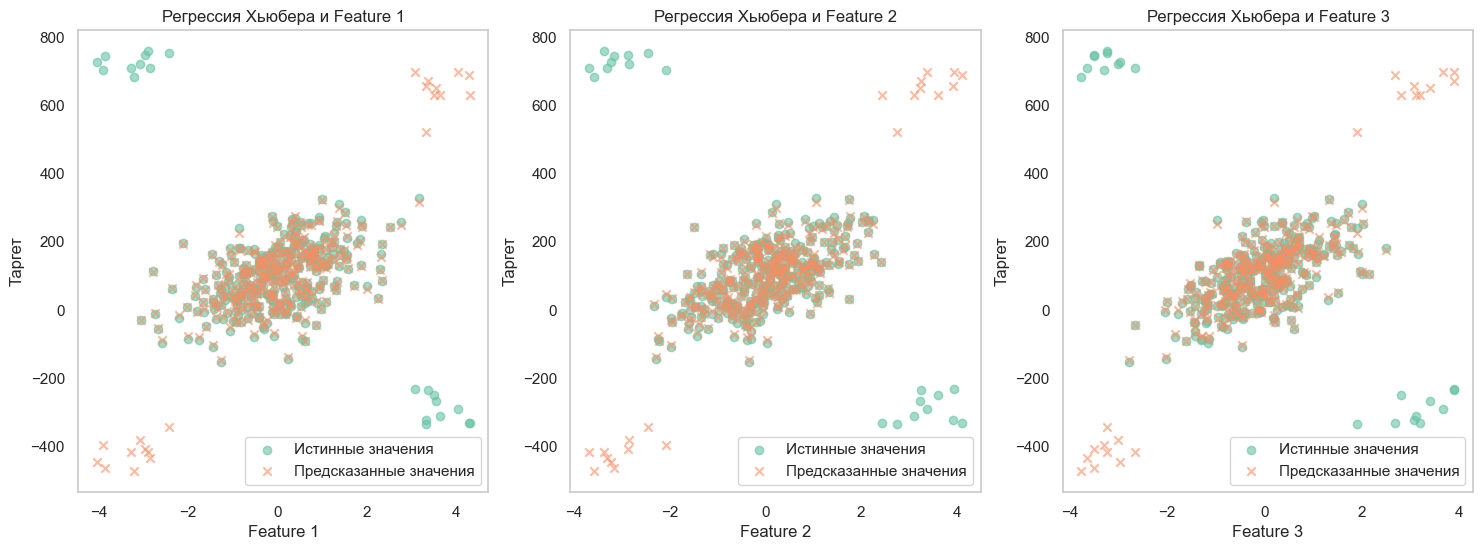

In [89]:
y_pred_hr = huber_model.predict(X_train)
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.scatter(X_train['feature_1'], y_train, label="Истинные значения", alpha=0.6, marker='o')
plt.scatter(X_train['feature_1'], y_pred_hr, label="Предсказанные значения", alpha=0.6, marker='x')
plt.xlabel("Feature 1")
plt.ylabel("Таргет")
plt.title("Регрессия Хьюбера и Feature 1")
plt.legend()
plt.grid()

plt.subplot(1, 3, 2)
plt.scatter(X_train['feature_2'], y_train, label="Истинные значения", alpha=0.6, marker='o')
plt.scatter(X_train['feature_2'], y_pred_hr, label="Предсказанные значения", alpha=0.6, marker='x')
plt.xlabel("Feature 2")
plt.ylabel("Таргет")
plt.title("Регрессия Хьюбера и Feature 2")
plt.legend()
plt.grid()

plt.subplot(1, 3, 3)
plt.scatter(X_train['feature_3'], y_train, label="Истинные значения", alpha=0.6, marker='o')
plt.scatter(X_train['feature_3'], y_pred_hr, label="Предсказанные значения", alpha=0.6, marker='x')
plt.xlabel("Feature 3")
plt.ylabel("Таргет")
plt.title("Регрессия Хьюбера и Feature 3")
plt.legend()
plt.grid()

plt.show()

У обычной модели предсказания гораздо меньше попадают в реальные значения, но при этом в группах выбросов предсказания гораздо точнее чем во второй модели (но все ещё так себе).
Вторая может очень хорошо угадывает значения для основной группы точек, но очень сильно ошибается в группах выбросов (прямо диаметрально противоположны правильный ответ и предположение :)).

Обучите регрессию Хьюбера на данных из задачи 2 из предыдущего ноутбука и сравните качество модели с простой линейной регрессией, которую вы построили в задаче 2.

In [90]:
df = pd.read_excel("bike+sharing+dataset/day.xlsx")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [91]:
train, test = train_test_split(df, test_size=0.2, random_state=42)

In [92]:
categorial_features = ["season", "mnth", "holiday", "weekday", "workingday", "weathersit"]
real_features = ["temp", "atemp", "hum", "windspeed"]
target_feature = "cnt"

In [93]:
X = train.drop(columns=['cnt', 'instant', 'dteday', 'yr', 'temp', 'atemp', 'casual', 'registered'])  
y = train['cnt']

X = X.to_numpy()
y = y.to_numpy()

In [94]:
model = HuberRegression(c=1.0, fit_intercept=True, max_iter=1000)
model.fit(X, y)

HuberRegression()

In [95]:
X_test = test.drop(columns=['cnt', 'instant', 'dteday', 'yr', 'temp', 'atemp', 'casual', 'registered', 'cnt'])

X_test = X_test.to_numpy()

cnt_preds = model.predict(X_test)

rmse = np.sqrt(((test['cnt'] - cnt_preds) ** 2).mean())

print("RMSE (cnt):", rmse)

RMSE (cnt): 1929.7848449765095


Регрессия Хьюбера очень хорошо, гораздо лучше обычной линейной регрессии работает на данных, в которых много выбросов, из-за того, что использует линейную функцию для подсчета ошибки на больших отклонениях (в том числе на всех выбросах). Поэтому для данных с большим количеством выбросов ее может быть довольно полезно использовать.
Но для данных, где выбросов не очень много, она не работает сильно эффективнее (у меня получилось, что точность стала даже меньше для примера из второй задачи), потому что ее основное преимущество - адаптивность к выбросам не имеет больше смысла.


---

Рассмотрим модель одномерной регрессии $y(x) = \theta x$, где $x \in \mathbb{R}$ &mdash; одномерный признак, $y \in \mathbb{R}$ &mdash; целевой признак, $\theta \in \mathbb{R}$ &mdash; неизвестный параметр. Имеется выборка размера $n$, полученная по правилу
	$$Y_i = \theta x_i + \varepsilon_i,\ \ \ i=1,...,n,$$
где $\varepsilon_i$ &mdash; случайная ошибка измерений.

Предложите точный алгоритм поиска оценки параметра $\theta$ методом наименьших модулей, то есть $$\sum_{i=1}^n \left|Y_i - \theta x_i\right| \to \min_\theta,$$ работающий за время $O(n \log n)$. Приведите его описание и теоретическое обоснование. Реализация в коде не требуется.


**Определение.** Пусть есть набор чисел $z_1, z_2, \dots, z_n$ с соответствующими весами $w_1, w_2, \dots, w_n$ (где все $w_i > 0$). Взвешенная медиана — это такое значение $\theta$, $\theta \in \{ z_1, z_2, \dots, z_n \}$, которое удовлетворяет:

$$
\sum_{i: z_i < \theta} w_i \leq \frac{1}{2} \sum_{i=1}^{n} w_i, \quad \sum_{i: z_i > \theta} w_i \leq \frac{1}{2} \sum_{i=1}^{n} w_i.
$$

**Утверждение 1.**   
Взвешенная медиана минимизирует функцию $S(\theta) = \sum_{i=1}^{n} w_i |z_i - \theta|$.  

Доказательство:
Для каждого фиксированного значения $\theta$, каждый член суммы $w_i |z_i - \theta|$ либо линейно убывает, либо линейно возрастает. В точке $z_i$ происходит излом, так как знак выражения $|z_i - \theta|$ меняется.  
Значит функция ошибки $S(\theta) = \sum_{i=1}^{n} w_i |z_i - \theta|$ является кусочно-линейной.  

Рассмотрим производную функции $S(\theta)$:

$$
S'(\theta) = -\sum_{i: z_i < \theta} w_i + \sum_{i: z_i > \theta} w_i.
$$

При $\theta$ меньше всех $z_i$, производная $S'(\theta)$ будет положительной, при $\theta$ больше всех $z_i$ - отрицательной.

Функция $S(\theta)$ достигает минимума в точке, где производная меняет знак. Это происходит в такой точке, где $\sum_{i: z_i < \theta} w_i - \sum_{i: z_i > \theta} w_i$ минимально. Это верно либо в одной, либо в двух точках, где выполняются неравенства.

$$
\sum_{i: z_i < \theta} w_i \leq \frac{1}{2} \sum_{i=1}^{n} w_i, \quad \sum_{i: z_i > \theta} w_i \leq \frac{1}{2} \sum_{i=1}^{n} w_i.
$$
Точка(и) в которой выполнены эти неравенства и является взвешенной медианой.

**Утверждение 2.**
$\sum_{i=1}^{n} |Y_i - \theta x_i| = \sum_{i=1}^{n} |x_i \left( \frac{Y_i}{x_i} - \theta \right)|$.

**Алгоритм 1 (поиск взвешенной медианы).**   

Нужно найти взвешенную медиану в массиве $z_1, z_2, \dots, z_n$ с весами $w_1, w_2, \dots, w_n$.
1. Сортируем по возрастанию $z_1, z_2, \dots, z_n$, сохраняя веса $w_1, w_2, \dots, w_n$. ($O(nlogn)$)  
2. Находим сумму всех весов $w = w_1 + w_2 + \dots + w_n$. ($O(n)$ - один проход)  
3. Идем по $[w_i]$, считаем префиксную сумму, находим $k$, т.ч. $\sum_{i=1}^{k - 1} w_i < \frac{1}{2}w$, a $\sum_{i=1}^{k} w_i \geq \frac{1}{2}w$. ($O(n)$ - один проход)
4. Ответ равен $k$.

Асимптотика: $O(nlogn)$.

**Алгоритм 2 (сведение задачи к медиане).**  

Нужно свести задачу поиска минимума $\sum_{i=1}^n \left|Y_i - \theta x_i\right|$ к задаче поиска взвешенной медианы.
1. Введем массив $z_1, z_2, \dots, z_n$, где $z_i = |\frac{Y_i}{x_i}|$. ($O(n)$ - один проход)
2. Согласно утверждениям 1 и 2 задача эквивалентна задаче поиска взвешенной медианы массива $z_1, z_2, \dots, z_n$ с весами $|x_i|, |x_i|, \dots, |x_i|$.

Асимптотика: $O(n)$.

**Алгоритм решения задачи.**
1. Свести задачу к задаче поиска взвешенной медианы по алгоритму 1. ($O(n)$)
2. Найти ответ по алгоритму 2. ($O(nlogn)$)  

Общая асимптотика: $O(nlogn)$.